In [1]:
from brainlit.preprocessing import removeSmallCCs
from brainlit.BrainLine.util import json_to_points, download_subvolumes
from brainlit.BrainLine.parse_ara import *
import xml.etree.ElementTree as ET
from brainlit.BrainLine.imports import *
from brainlit.BrainLine.apply_ilastik import (
    ApplyIlastik,
    ApplyIlastik_LargeImage,
    plot_results,
    examine_threshold,
)
from brainlit.BrainLine.analyze_results import (
    AxonDistribution,
    collect_regional_segmentation,
)
from scipy.special import rel_entr
from itertools import combinations
import networkx as nx
from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.formula.api import ols

%gui qt5

In [3]:
brainlit_path = Path(os.path.abspath(""))
brainlit_path = brainlit_path.parents[1]
print(f"Path to brainlit: {brainlit_path}")
data_file = brainlit_path / "experiments" / "BrainLine" / "data" / "axon_data.json"

with open(data_file) as f:
    data = json.load(f)
brain2paths = data["brain2paths"]


axon_data_dir = "/home/user/brainlit/experiments/BrainLine/data/validation-and-models/axon/"  # path to directory where training/validation data should be stored

Path to brainlit: /home/user/brainlit


In [8]:
brain_ids = [
    # "3",
    # "4",
    "8613",
    # "8604",
    "8650",
    "8589",
    # "8590",
    # "8649",
    "8788",
    "8786",
    "11537",
    "8790",
    "MS32",
    "MS29",
    "MS11",
    "MS15",
    "MS12",  # registration not found
    "MS33",
    "MS9",
]  # list of sample IDs to be shown



colors = {
    "tph2 gad2": "green",
    "tph2 vglut3": "blue",
    "gad2 vgat": "red",
}  # colors for different genotypes
fold_on = True
ontology_file = (
    brainlit_path / "brainlit" / "BrainLine" / "data" / "ara_structure_ontology.json"
)
ontology_fixes = (
    brainlit_path / "brainlit" / "BrainLine" / "data" / "open-nd-ara-fixes.json"
)

axon_data_dir = "/home/user/brainlit/experiments/BrainLine/data/wholebrain-results/axon/"



ad = AxonDistribution(
    brain_ids=brain_ids,
    regional_distribution_dir=axon_data_dir,
    data_file=data_file,
    ontology_file=ontology_file,
    fixes_file=ontology_fixes,
)

custom_regions = [688, 1097, 549, 354, 512, 477, 313]

In [13]:
regions = [
    500,  # somatomotor
    453,  # somatosensory
    972,  # prelimbic
    44,  # infralimbic
    477,
    1089,
    1097,  # hypothalamus
    549,  # thalamus
    186,  # lateral habenula
    351,  # bed nuclei of stria terminalis
    #313,  # midbrain
    512,  # cerebellum
    771,  # pons
    354,  # medulla
]  # allen atlas region IDs to be shown
# see: https://connectivity.brain-map.org/projection/experiment/480074702?imageId=480075280&initImage=TWO_PHOTON&x=17028&y=11704&z=3

composite_regions = {
    "Amygdala": [131, 295, 319, 536, 780],
    # "Substantia Nigra": [615, 374, 374],
    # "Superior Colliculus": [294, 302],
}  # Custom composite allen regions where key is region name and value is list of allen regions

In [14]:
def _log_ttest_ind(group_data1, group_data2, verbose=1, **stats_params):
    group_data1_log = np.log(group_data1)
    group_data2_log = np.log(group_data2)

    return ttest_ind(group_data1_log, group_data2_log, **stats_params)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Somatosensory areas_tph2 gad2 (n=5) vs. Somatosensory areas_gad2 vgat (n=4): Log t-test_ind with Benjamini-Hochberg correction, P_val:6.142e-01 Stat=5.274e-01
Prelimbic area_tph2 gad2 (n=5) vs. Prelimbic area_gad2 vgat (n=4): Log t-test_ind with Benjamini-Hochberg correction, P_val:9.758e-01 Stat=-3.144e-02
Prelimbic area_tph2 vglut3 (n=5) vs. Prelimbic area_tph2 gad2 (n=5): Log t-test_ind with Benjamini-Hochberg correction, P_val:9.836e-03 Stat=3.367e+00
Infralimbic area_tph2 gad2 (n=5) vs. Infralimbic area_gad2 vgat (n=4): Log t-test_ind with Benjamini-Hochberg correction, P_val:7.102e-01 Stat=3.871e-01
Infralimbic area_tph2 vglut3 (n=5) vs. Infralimbic area_tph2 gad2 (n=5): Log t-test_ind with Benjamini-Hochberg correction, P_val:2.841e-01 Stat=1.148e+00
Striatum_tph2 gad2 (n=5) vs. Striatum_ga

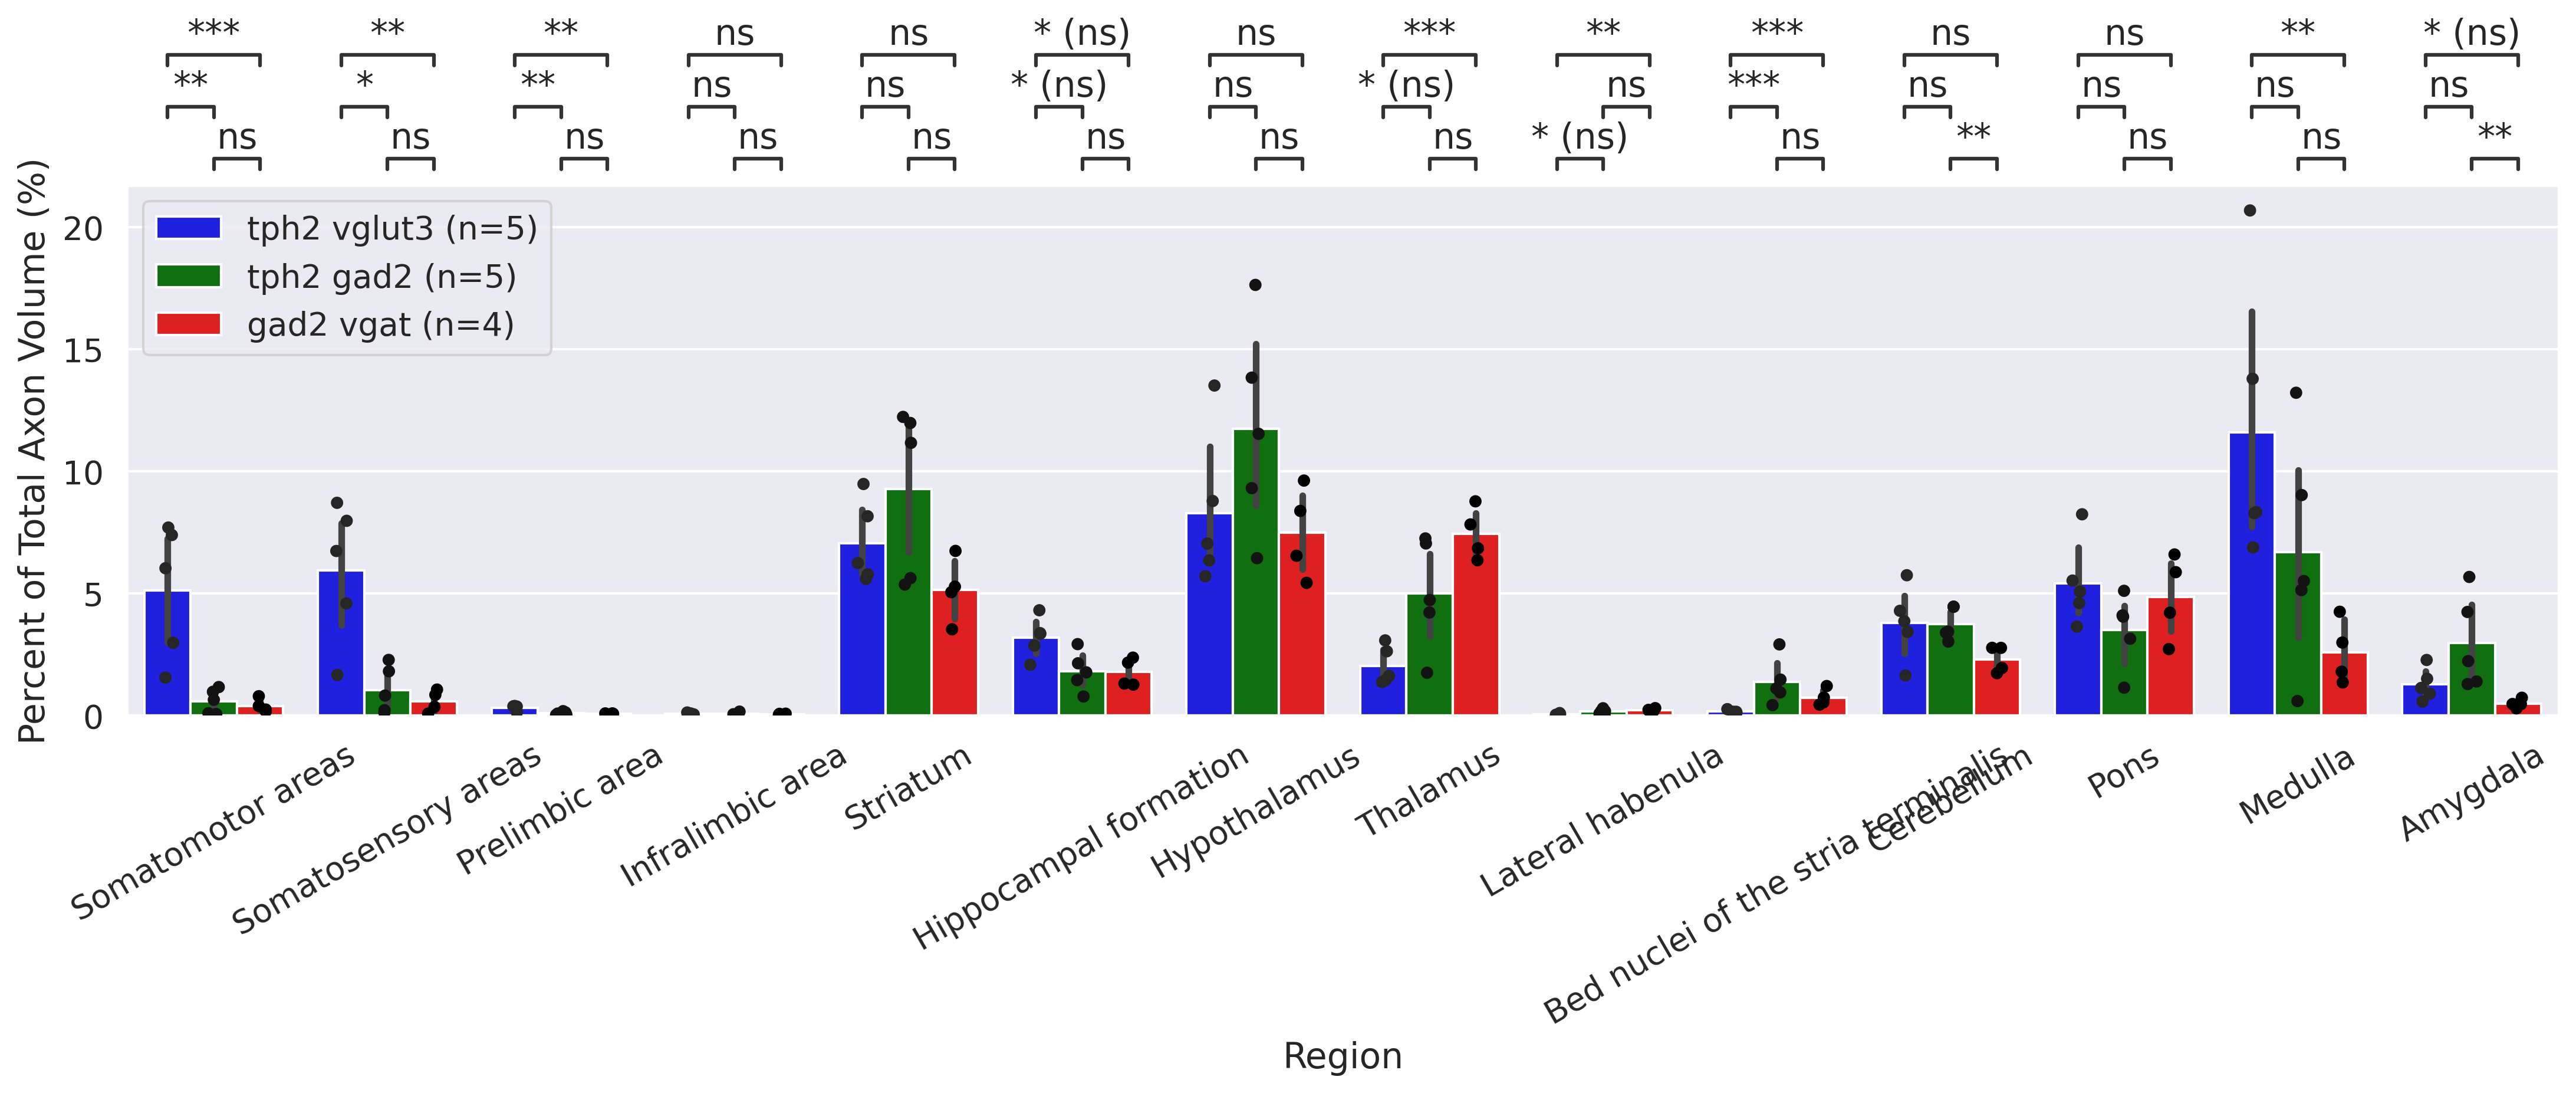

In [15]:
test = StatTest(
    _log_ttest_ind, test_long_name="Log t-test_ind", test_short_name="log-t"
)
#test = "Mann-Whitney"
#test = "t-test_ind"

region_names = []
pcts = []
total_vols = []
reg_vols = []
ids = []
subtypes = []
subtype_counts = {}

for brain_id in ad.brain_ids:
    subtype = ad.brain2paths[brain_id]["subtype"]
    total_vol = ad.region_graph.nodes[997][f"{brain_id} axon"]

    if subtype in subtype_counts.keys():
        subtype_counts[subtype] = subtype_counts[subtype] + 1
    else:
        subtype_counts[subtype] = 1

    for region in regions:
        reg_vol = ad.region_graph.nodes[region][f"{brain_id} axon"]
        pct = (
            reg_vol / total_vol
            * 100
        )

        reg_vols.append(reg_vol)
        total_vols.append(total_vol)
        pcts.append(pct)
        subtypes.append(subtype)
        ids.append(brain_id)
        region_names.append(ad.region_graph.nodes[region]["name"])
    for composite_region in composite_regions.keys():
        composite_region_regions = composite_regions[composite_region]
        reg_vol = 0
        for region in composite_region_regions:
            reg_vol += ad.region_graph.nodes[region][f"{brain_id} axon"]

        reg_vols.append(reg_vol)
        total_vols.append(total_vol)
        pcts.append(reg_vol / total_vol * 100)
        subtypes.append(subtype)
        ids.append(brain_id)
        region_names.append(composite_region)


# append n to subtypes
color_palette = {}
for i, subtype in enumerate(subtypes):
    new_key = subtype + f" (n={subtype_counts[subtype]})"
    subtypes[i] = new_key
    color_palette[new_key] = colors[subtype] 

data = {
    "Region": region_names,
    "Brain ID": ids,
    "Subtype": subtypes,
    "Axon Volume (pixels)": reg_vols,
    "Total Axon Volume (pixels)": total_vols,
    "Percent of Total Axon Volume (%)": pcts,
}
df = pd.DataFrame(data=data)

diffs = []
for region_name in df["Region"].unique():
    diff = (
        df[(df["Region"] == region_name) & (df["Subtype"] == "tph2 gad2")][
            "Percent of Total Axon Volume (%)"
        ].mean()
        - df[(df["Region"] == region_name) & (df["Subtype"] == "tph2 vglut3")][
            "Percent of Total Axon Volume (%)"
        ].mean()
    )
    diffs.append((region_name, diff))


def second(e):
    return e[1]


diffs.sort(key=second, reverse=False)
order = [e[0] for e in diffs]

sns.set(font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(15, 7), dpi=300)
fig_args = {
    "y": "Percent of Total Axon Volume (%)",
    "x": "Region",
    "hue": "Subtype",
    "data": df,
    "dodge": True,
}
bplot = sns.stripplot(ax=ax, color='black', order=order, **fig_args)
# fig_args["boxprops"] = {"facecolor": "none"}
# bplot = sns.boxplot(ax=ax, order=order, **fig_args)
bplot = sns.barplot(ax=ax, palette=color_palette, **fig_args)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles[3:], labels=labels[3:])

#bplot.set_yscale("log")
xtick_labels = bplot.get_xticklabels()
# for i, x_lbl in enumerate(xtick_labels):
#     if x_lbl.get_text() == "Bed nuclei of the stria terminalis":
#         xtick_labels[i].set_text("BNST")
#         break
bplot.set_xticklabels(labels=xtick_labels, rotation=30)

# annotator
fig_args["x"] = "Region"
fig_args["y"] = "Percent of Total Axon Volume (%)"
pairs = []
unq_subtypes = np.unique(subtypes)
for region in regions + ["Amygdala"]:
    if region == "Amygdala":
        region_name = region
    else:
        region_name = ad.region_graph.nodes[region]["name"]

    for i, subtype1 in enumerate(unq_subtypes):
        for subtype2 in unq_subtypes[i + 1 :]:
            pairs.append(((region_name, subtype1), (region_name, subtype2)))
annot = Annotator(ax, pairs, **fig_args)
annot.configure(
    test=test, text_format="star", loc="outside", comparisons_correction="BH"
)
fig_args["x"] = "Region"
fig_args["y"] = "Percent of Total Axon Volume (%)"
annot.new_plot(bplot, orient="v", plot="boxplot", **fig_args)
annot.apply_and_annotate()

# markers = ["o", "v", "^", "<", ">", "s", "p", "*", "+", "x", "D"]
# jitters = {"tph2 vglut3": -0.26, "tph2 gad2": 0, "gad2 vgat": 0.26}
# id2marker = {id: markers[idx] for idx, id in enumerate(brain_ids)}
# for idx, line in df.iterrows():
#     st = line["Subtype"].split("(")[0][:-1]

#     x = line["Percent of Total Axon Volume (%)"]
#     y = order.index(line["Region"]) + jitters[st]
#     c = colors[st]
#     marker = id2marker[line["Brain ID"]]
#     ax.scatter([x], [y], c=c, marker=marker)


fig.tight_layout()
